# Week 3 Day 6 — House Prices Kaggle Competition

## What I built:
- Loaded House Prices dataset (1460 rows, 81 features)
- EDA — SalePrice distribution, log transform, top correlations
- Feature engineering — 7 new features
- Full Pipeline — 36 numeric + 43 categorical features
- Random Forest Regressor — 300 trees, depth=15
- 2 Kaggle submissions

## EDA findings:
- SalePrice skewness: 1.88 → 0.12 after log1p transform
- Top correlated features: OverallQual, GrLivArea,
  GarageCars, GarageArea, TotalBsmtSF
- Missing values: PoolQC (1453), MiscFeature (1406),
  Alley (1369) — pipeline handles automatically

## Feature engineering:
- TotalSF      = TotalBsmtSF + 1stFlrSF + 2ndFlrSF
- TotalBath    = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
- HouseAge     = YrSold - YearBuilt
- RemodAge     = YrSold - YearRemodAdd
- HasPool      = PoolArea > 0
- HasGarage    = GarageArea > 0
- HasBasement  = TotalBsmtSF > 0

## Results:
CV RMSE (basic RF)          : 0.1503
CV RMSE (with engineering)  : 0.1457 ← improved

## Kaggle scores:
v1 Basic Random Forest           : 0.15197
v2 RF + feature engineering      : 0.14864 ← best (top 40%)

## Key rule:
Always log-transform skewed regression targets.
log1p before training → expm1 after predicting → real prices back.

# Load and explore:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# download from kaggle.com/c/house-prices-advanced-regression-techniques
train = pd.read_csv('house_prices_train.csv')
test  = pd.read_csv('house_prices_test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nTarget (SalePrice) stats:")
print(train['SalePrice'].describe())
print("\nMissing values (top 10):")
print(train.isnull().sum().sort_values(ascending=False).head(10))

Train shape: (1460, 81)
Test shape : (1459, 80)

Target (SalePrice) stats:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Missing values (top 10):
PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64


# EDA on House Prices:

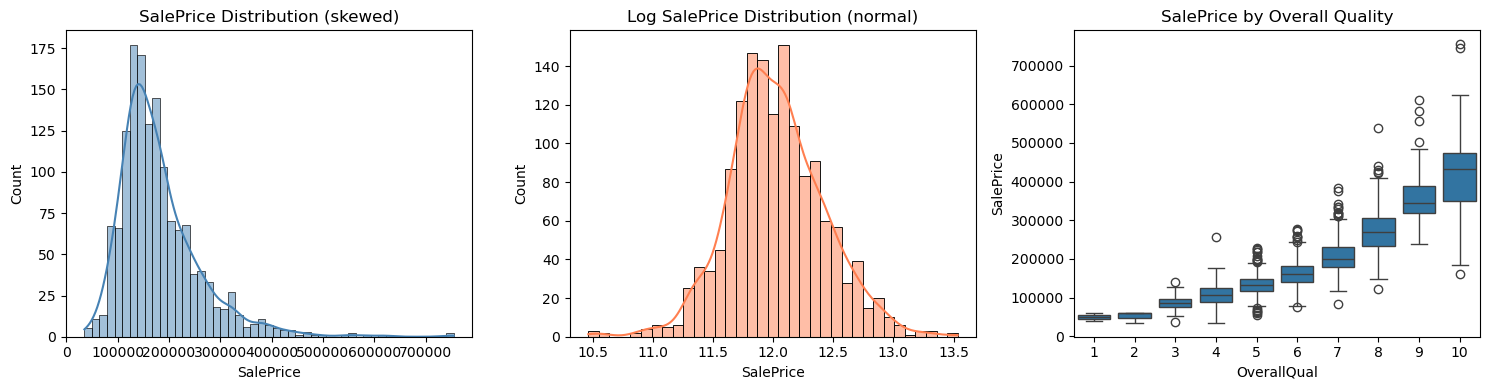

SalePrice skewness          : 1.8829
Log SalePrice skewness      : 0.1213
Most correlated with price  : ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. SalePrice distribution
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice Distribution (skewed)')

# 2. Log-transformed SalePrice
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log SalePrice Distribution (normal)')

# 3. SalePrice vs OverallQual
sns.boxplot(x='OverallQual', y='SalePrice', data=train, ax=axes[2])
axes[2].set_title('SalePrice by Overall Quality')

plt.tight_layout()
plt.savefig('house_prices_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"SalePrice skewness          : {train['SalePrice'].skew():.4f}")
print(f"Log SalePrice skewness      : {np.log1p(train['SalePrice']).skew():.4f}")
print(f"Most correlated with price  : {train.corr(numeric_only=True)['SalePrice'].abs().nlargest(6).index.tolist()}")

# Feature engineering and preprocessing:

In [3]:
# log transform target
y_train = np.log1p(train['SalePrice'])

# drop target and ID
X_train_raw = train.drop(columns=['SalePrice', 'Id'])
X_test_raw  = test.drop(columns=['Id'])

# separate numeric and categorical
num_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features   : {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Total features     : {len(num_cols) + len(cat_cols)}")
print(f"\nNumeric cols sample   : {num_cols[:5]}")
print(f"Categorical cols sample: {cat_cols[:5]}")

Numeric features   : 36
Categorical features: 43
Total features     : 79

Numeric cols sample   : ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']
Categorical cols sample: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']


# Build full pipeline and train:

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

# numeric transformer
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# categorical transformer
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# combine
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# pipeline with Random Forest Regressor
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        max_features='sqrt',
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# evaluate with KFold — regression uses KFold not StratifiedKFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_pipe, X_train_raw, y_train,
                         cv=kfold,
                         scoring='neg_root_mean_squared_error')

print("=" * 45)
print("   HOUSE PRICES — RANDOM FOREST")
print("=" * 45)
print(f"  CV RMSE scores : {-scores.round(4)}")
print(f"  Mean RMSE      : {-scores.mean():.4f}")
print(f"  Std RMSE       : {scores.std():.4f}")
print("=" * 45)

   HOUSE PRICES — RANDOM FOREST
  CV RMSE scores : [0.1637 0.1381 0.1563 0.1646 0.1291]
  Mean RMSE      : 0.1503
  Std RMSE       : 0.0143


# Kaggle submission:

In [5]:
# fit on full training data
rf_pipe.fit(X_train_raw, y_train)

# predict on test
log_predictions = rf_pipe.predict(X_test_raw)

# convert back from log scale
predictions = np.expm1(log_predictions)

# create submission
submission = pd.DataFrame({
    'Id'       : test['Id'],
    'SalePrice': predictions
})
submission.to_csv('house_prices_submission.csv', index=False)
print("Submission saved!")
print(submission.head())
print(f"\nPrediction range: ${predictions.min():,.0f} to ${predictions.max():,.0f}")

Submission saved!
     Id      SalePrice
0  1461  124468.148212
1  1462  150772.301271
2  1463  184530.546189
3  1464  185599.630256
4  1465  191107.943170

Prediction range: $70,197 to $412,225


# Add feature engineering:

In [6]:
# add these features before pipeline
def engineer_features(df):
    df = df.copy()
    
    # total area
    df['TotalSF']      = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    
    # total bathrooms
    df['TotalBath']    = (df['FullBath'] + 0.5 * df['HalfBath'] +
                          df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
    
    # house age
    df['HouseAge']     = df['YrSold'] - df['YearBuilt']
    df['RemodAge']     = df['YrSold'] - df['YearRemodAdd']
    
    # has features flags
    df['HasPool']      = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']    = (df['GarageArea'] > 0).astype(int)
    df['HasBasement']  = (df['TotalBsmtSF'] > 0).astype(int)
    
    return df

# apply to both train and test
X_train_fe = engineer_features(X_train_raw)
X_test_fe  = engineer_features(X_test_raw)

# update num_cols with new features
new_num_cols = num_cols + ['TotalSF', 'TotalBath', 'HouseAge', 
                            'RemodAge', 'HasPool', 'HasGarage', 'HasBasement']

# rebuild preprocessor with new columns
preprocessor_fe = ColumnTransformer(transformers=[
    ('num', num_transformer, new_num_cols),
    ('cat', cat_transformer, cat_cols)
])

rf_pipe_fe = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=15,
        max_features='sqrt', min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ))
])

# evaluate
scores_fe = cross_val_score(rf_pipe_fe, X_train_fe, y_train,
                             cv=kfold,
                             scoring='neg_root_mean_squared_error')

print("=" * 45)
print("   WITH FEATURE ENGINEERING")
print("=" * 45)
print(f"  Mean RMSE : {-scores_fe.mean():.4f}  (was 0.1503)")
print(f"  Std RMSE  : {scores_fe.std():.4f}")
print("=" * 45)

   WITH FEATURE ENGINEERING
  Mean RMSE : 0.1457  (was 0.1503)
  Std RMSE  : 0.0144


# Submit this improved version:

In [7]:
# fit on full training data with feature engineering
rf_pipe_fe.fit(X_train_fe, y_train)

# predict on test
log_predictions_fe = rf_pipe_fe.predict(X_test_fe)
predictions_fe = np.expm1(log_predictions_fe)

# create submission
submission_fe = pd.DataFrame({
    'Id'       : test['Id'],
    'SalePrice': predictions_fe
})
submission_fe.to_csv('house_prices_submission_v2.csv', index=False)
print("Submission v2 saved!")
print(f"Prediction range: ${predictions_fe.min():,.0f} to ${predictions_fe.max():,.0f}")

Submission v2 saved!
Prediction range: $68,186 to $428,049
